In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

GenerationReport(requested=10000, generated=10000, failed=0, total_attempts=10000, failure_reasons={}, parameter_ranges={'fill_fraction': (0.0015716552734375, 0.916534423828125)}, metadata={'generator': 'RandomUnitCellGenerator', 'generated_at': '2026-04-06T16:06:35', 'canvas': 'Canvas(Lx=1, Ly=1, H=256, W=256, xc=0.0, yc=0.0, spacing=0)', 'config': {'seed': 40, 'target_count': 10000, 'max_tries_per_shape': 100, 'max_tries_per_cell': 100, 'fixed_num_shapes': 1, 'min_num_shapes': 1, 'max_num_shapes': 3, 'allowed_shapes': ('Rectangle',), 'shape_weights': {}, 'fixed_shape_params': {'Rectangle': {}}, 'shape_param_ranges': {'Rectangle': {'angle': (0, 90)}}, 'fixed_canvas_Lx': 1.0, 'fixed_canvas_Ly': None, 'canvas_Lx_range': None, 'canvas_Ly_range': (0.5, 2.0), 'min_shape_size': 0.05, 'min_feature_size': 0.05, 'min_gap': 0.0, 'extra': {}, 'require_nonempty_after_clip': True}})
10000


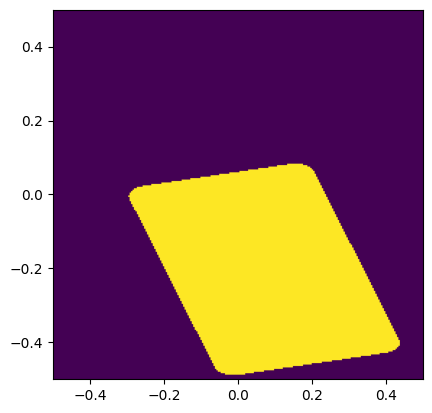

In [2]:
from metashapes.generators.random import RandomGeneratorConfig, RandomUnitCellGenerator
from metashapes.generators.validator import DefaultUnitCellValidator
from metashapes.canvas import Canvas
from metashapes.analysis import UnitCellAnalyzer
from metashapes.adapters import save_batch_result, load_batch_result

cfg = RandomGeneratorConfig(
    target_count=10000,
    fixed_num_shapes=1,
    allowed_shapes=("Rectangle",),
    min_shape_size=0.05,
    min_feature_size=0.05,
    min_gap=0.0,
    seed=40,
    max_tries_per_cell=100,
    max_tries_per_shape=100,
    fixed_shape_params={
        "Rectangle": {
            #"center": (0, 0),
            #"axes": (450, 450),
            #'corner_radius': 10,
        },
        
    },
    shape_param_ranges={
        "Rectangle": {
            #"size": ((200, 250), (100, 150)),
            "angle": (0, 90),
        }},
    fixed_canvas_Lx=1.0,
    canvas_Ly_range=(0.5, 2.0)
)

canvas = Canvas(Lx=1, Ly=1, W=256, H=256, spacing=0)

gen = RandomUnitCellGenerator(cfg, validator=DefaultUnitCellValidator())
result = gen.generate(canvas)

print(result.report)
print(len(result.unit_cells))

plt.imshow(result.unit_cells[3].mask_numpy(), origin='lower', extent=(-canvas.Lx/2, canvas.Lx/2, -canvas.Ly/2, canvas.Ly/2))
#result.unit_cells[2].to_shapely()

In [3]:
save_batch_result("rectangles_10k.yaml", result)

In [7]:
results_new = load_batch_result("rectangles_10k.yaml")

In [8]:
len(results_new.unit_cells)

10000

In [20]:
analyzer = UnitCellAnalyzer()
#metrics = analyzer.analyze(result.unit_cells)
analyzer.find_duplicates(result.unit_cells)

[]

[]

(array([ 98., 104., 111., 105.,  94., 100.,  94., 104., 100.,  90.]),
 array([0.50250467, 0.65202414, 0.80154362, 0.95106309, 1.10058256,
        1.25010204, 1.39962151, 1.54914098, 1.69866045, 1.84817993,
        1.9976994 ]),
 <BarContainer object of 10 artists>)

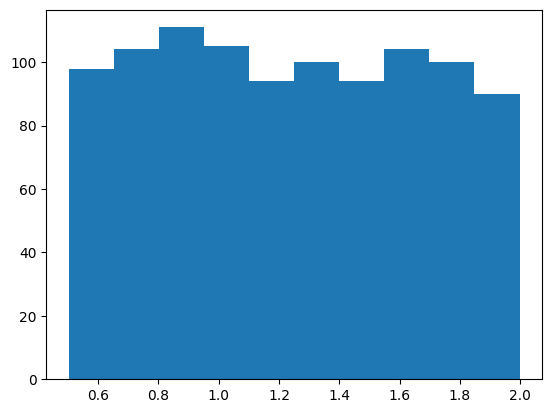

In [7]:
plt.hist([uc.canvas.Ly for uc in result.unit_cells])

(array([259., 268., 222., 217., 184., 179., 156., 186., 155., 174.]),
 array([6.86701254e-02, 9.05947091e+00, 1.80502717e+01, 2.70410725e+01,
        3.60318733e+01, 4.50226741e+01, 5.40134748e+01, 6.30042756e+01,
        7.19950764e+01, 8.09858772e+01, 8.99766780e+01]),
 <BarContainer object of 10 artists>)

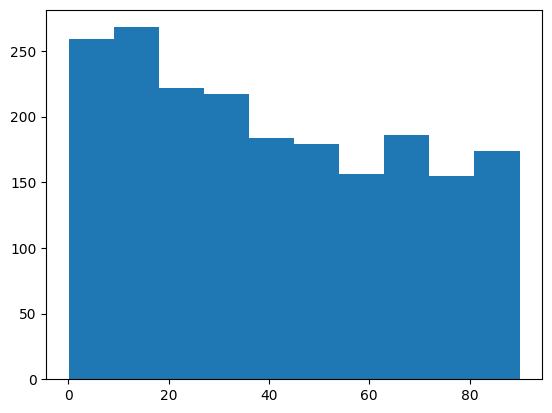

In [26]:
plt.hist([uc.shape.angle for uc in result.unit_cells])

(array([254., 208., 191., 142., 100.,  57.,  22.,  13.,   7.,   6.]),
 array([0.05003626, 0.22779151, 0.40554676, 0.583302  , 0.76105725,
        0.9388125 , 1.11656774, 1.29432299, 1.47207824, 1.64983348,
        1.82758873]),
 <BarContainer object of 10 artists>)

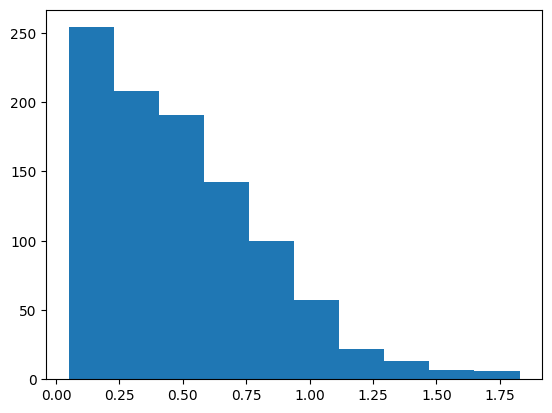

In [17]:
plt.hist([uc.shape.size[1] for uc in result.unit_cells])

(array([782., 501., 280., 171., 117.,  81.,  33.,  21.,  12.,   2.]),
 array([1.41386509e-04, 3.75377477e-02, 7.49341090e-02, 1.12330470e-01,
        1.49726831e-01, 1.87123193e-01, 2.24519554e-01, 2.61915915e-01,
        2.99312276e-01, 3.36708638e-01, 3.74104999e-01]),
 <BarContainer object of 10 artists>)

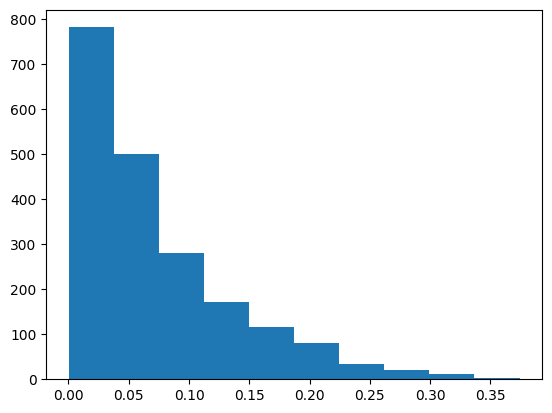

In [52]:
plt.hist([uc.shape.corner_radius for uc in result.unit_cells])

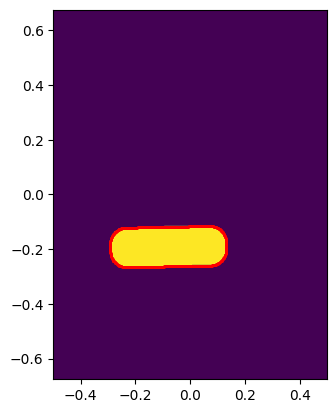

In [51]:
fig, ax = plt.subplots()

# show the mask
cell = result.unit_cells[30]

c = cell.canvas
plt.imshow(cell.mask_numpy(), origin='lower',
           extent=(c.x0, c.x1, c.y0, c.y1))
# overlay boundary points
pts = cell.boundary_points()  # shape (N, 2) in physical coords
ax.scatter(pts[:, 0], pts[:, 1], s=1, c='red')

plt.show()

/Users/rodionsa/mambaforge/envs/shapes/lib/python3.13/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


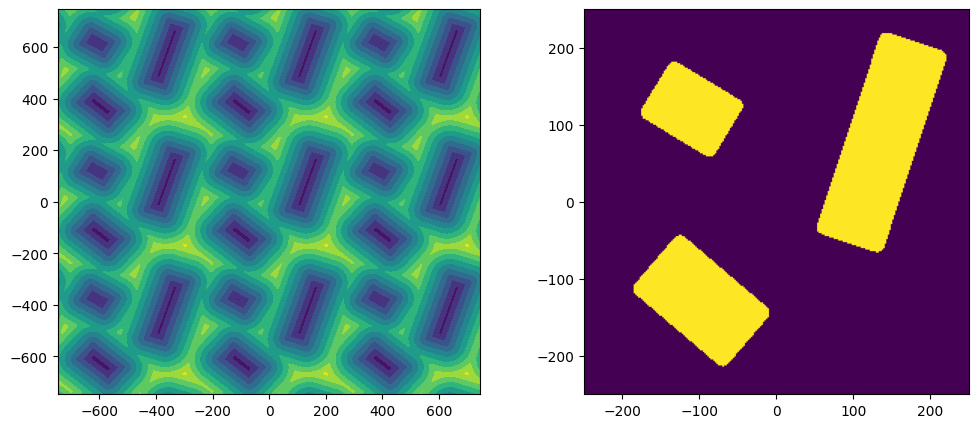

In [4]:
import torch

periods= 3

x1 = torch.linspace(-periods*canvas.Lx/2, periods*canvas.Lx/2, 300)
y1 = torch.linspace(-periods*canvas.Ly/2, periods*canvas.Ly/2, 300)

y, x = torch.meshgrid(y1, x1)

sdf = result.unit_cells[5].sdf(x, y)
im = result.unit_cells[5].mask_numpy()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.contourf(sdf.detach().numpy(), origin='lower', extent=(-periods*canvas.Lx/2, periods*canvas.Lx/2, -periods*canvas.Ly/2, periods*canvas.Ly/2), levels=10)

plt.subplot(1, 2, 2)
plt.imshow(im, origin='lower', extent=(-canvas.Lx/2, canvas.Lx/2, -canvas.Ly/2, canvas.Ly/2))

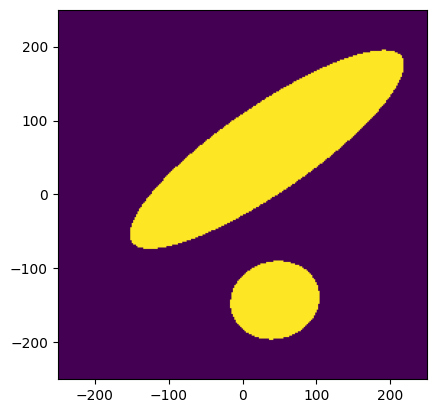

In [20]:
plt.imshow(result.unit_cells[5].mask_numpy(), origin='lower', extent=(-canvas.Lx/2, canvas.Lx/2, -canvas.Ly/2, canvas.Ly/2))